# **Aprendizaje Automatico - Proyecto Final**

**Tema:** Clasificación del Riesgo de Inundación por Parroquia en Zonas Lluviosas del Ecuador

**Grupo C**

**Integrantes:**

*   Caicho Shanney
*   Cedeño Scarlett
*   Moya Ivan
*   Ordoñez Cosme
*   Salavarria Alejandra









In [1]:
# Importacion de librerias
import geopandas as gpd # Lectura de archivo shapefile
import pandas as pd
import os
import requests # Interaccion con la web
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point # Representtacion de los puntos geomtericos aplicadas altitud y pendiente
from sklearn.linear_model import LogisticRegression #modelo de Regresion Logistica
from sklearn.preprocessing import StandardScaler #Herramienta de escalado
from sklearn.ensemble import RandomForestClassifier #modelo de ensamble Random Forest
from sklearn.model_selection import train_test_split, cross_val_score #herramientas de entrenamiento y validacion cruzada
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report #para metricas de evaluacion

# Librerias adicionales necesarias para el Tema 4
from sklearn.svm import SVC # modelo SVM (Support Vector Machine)
from sklearn.tree import DecisionTreeClassifier # Arbol de Decision, requerido para el modelo ensamble
from sklearn.ensemble import VotingClassifier # combinacion de modelos en un ensamble
from sklearn.model_selection import GridSearchCV # busqueda de hiperparametros
from sklearn.metrics import roc_curve, auc, roc_auc_score # evaluacion mediante curva ROC y AUC
from sklearn.preprocessing import label_binarize # necesario para calcular ROC en problemas multiclase
import gdown
import warnings
warnings.filterwarnings('ignore')

# Fijacion global de la semilla de aleatoriedad
# Mejorando la reproducibilidad en todo el notebook
np.random.seed(19)

In [2]:
url = "https://drive.google.com/drive/folders/1Geu3D7-a-3eQ__fz2DE7djv5LZtnw2JX?usp=sharing"
output = "content/data_riesgo_inundaciones"
gdown.download_folder(url=url, output=output, quiet=False)

Retrieving folder contents


Retrieving folder 15xGBk5Ua_XroLX0MnJI2sQjVeWk_OI1t clima_precipitaciones
Processing file 1NiA96vDSQvOdDWHNvmAA0IxeNOWI4IN7 inamhi-precipitacion-2019diciembre.csv
Retrieving folder 1_ADnBoZrTAV5-EkfRbQkkpLGDDSUgdD1 cuerpos_agua
Processing file 1eABkSrPpQSA_aQmuGsSSa1jK6iw4Vimu UNIDADES_HIDROGRAFICAS_NIVEL5.dbf
Processing file 16YD1W-zfOHX2peXvLu-YpNdETXqykmhe UNIDADES_HIDROGRAFICAS_NIVEL5.prj
Processing file 1-rU3b4IDSFW15eUP2c7M6UccbbXjC_s3 UNIDADES_HIDROGRAFICAS_NIVEL5.sbn
Processing file 17_jDLOaKbDCULxikFrojkbekrnMhEMfx UNIDADES_HIDROGRAFICAS_NIVEL5.sbx
Processing file 11Udr_5hilrUK4MxdOarZ6eOJceDesoDS UNIDADES_HIDROGRAFICAS_NIVEL5.shp
Processing file 1DETlU0rgPrQ9Igd4klz-T3wW6IUd7vYP UNIDADES_HIDROGRAFICAS_NIVEL5.shp.xml
Processing file 1MfqG_QWYL7kOPR3g8aS9mg9L_7tPXWpV UNIDADES_HIDROGRAFICAS_NIVEL5.shx
Retrieving folder 1B-jKDB5L3Q5-rWOo_u8MaC0XF7eC0OZY densidad_poblacional
Processing file 1fKavxYIpju1eVLoS31dHIwqIdg56XRHa PRUEBA DENSIDAD POBLACIONAL.xlsx
Retrieving folder 1YTG2Z

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1NiA96vDSQvOdDWHNvmAA0IxeNOWI4IN7
To: /content/content/data_riesgo_inundaciones/clima_precipitaciones/inamhi-precipitacion-2019diciembre.csv
100%|██████████| 2.20M/2.20M [00:00<00:00, 60.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eABkSrPpQSA_aQmuGsSSa1jK6iw4Vimu
To: /content/content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.dbf
100%|██████████| 261k/261k [00:00<00:00, 33.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=16YD1W-zfOHX2peXvLu-YpNdETXqykmhe
To: /content/content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.prj
100%|██████████| 409/409 [00:00<00:00, 1.24MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-rU3b4IDSFW15eUP2c7M6UccbbXjC_s3
To: /content/content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.sbn
100%|███████

['content/data_riesgo_inundaciones/clima_precipitaciones/inamhi-precipitacion-2019diciembre.csv',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.dbf',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.prj',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.sbn',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.sbx',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.shp',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.shp.xml',
 'content/data_riesgo_inundaciones/cuerpos_agua/UNIDADES_HIDROGRAFICAS_NIVEL5.shx',
 'content/data_riesgo_inundaciones/densidad_poblacional/PRUEBA DENSIDAD POBLACIONAL.xlsx',
 'content/data_riesgo_inundaciones/parroquias/nxparroquias.dbf',
 'content/data_riesgo_inundaciones/parroquias/nxparroquias.prj',
 'content/data_riesgo_inundaciones/parroquias/nxparroquias.sbn',
 'content/data_riesgo_in

**Carga  y visualizacion de los datasets**

In [3]:
# Dataset - distribucion geopolitica del Ecuador
parroquias = gpd.read_file("/content/content/data_riesgo_inundaciones/parroquias")

# Dataset - precipitaciones
precipitacion = pd.read_csv('/content/content/data_riesgo_inundaciones/clima_precipitaciones/inamhi-precipitacion-2019diciembre.csv', encoding='latin-1', sep=';')

meses = ['ene','feb','mar','abr','may','jun','jul','ago','sep','oct','nov','dic']

# Convercion coma decimal a punto, y a float
for col in meses + ['longitud2', 'latitud2']:
    precipitacion[col] = (
        precipitacion[col].astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

precipitacion.dtypes

# Dataset - Densidad poblacional
densidad = pd.read_excel("/content/content/data_riesgo_inundaciones/densidad_poblacional/PRUEBA DENSIDAD POBLACIONAL.xlsx")

In [4]:
# Filtrado de parroquias
parroquias_filtradas = parroquias[parroquias["DPA_DESPRO"].isin(["LOS RIOS", "GUAYAS"])].copy()

# Conversion GeoJson para app Flask
parroquias_filtradas.to_file("parroquias.geojson", driver="GeoJSON")

# Visualizacion del dataset - Parroquias
print(parroquias_filtradas.columns)
parroquias_filtradas.head()


Index(['DPA_PARROQ', 'DPA_DESPAR', 'DPA_VALOR', 'DPA_ANIO', 'DPA_CANTON',
       'DPA_DESCAN', 'DPA_PROVIN', 'DPA_DESPRO', 'geometry'],
      dtype='object')


,DPA_PARROQ,DPA_DESPAR,DPA_VALOR,DPA_ANIO,DPA_CANTON,DPA_DESCAN,DPA_PROVIN,DPA_DESPRO,geometry
658,090150,GUAYAQUIL,0,2012,0901,GUAYAQUIL,09,GUAYAS,"MULTIPOLYGON (((588584.686 9702837.227, 588541..."
659,090152,JUAN GOMEZ RENDON (PROGRESO),0,2012,0901,GUAYAQUIL,09,GUAYAS,"POLYGON ((579404.191 9727655.926, 579409.588 9..."
660,090153,MORRO,0,2012,0901,GUAYAQUIL,09,GUAYAS,"POLYGON ((579404.191 9727655.926, 579374.103 9..."
661,090156,POSORJA,0,2012,0901,GUAYAQUIL,09,GUAYAS,"POLYGON ((576717.133 9699890.123, 576697.76 96..."
662,090157,PUNA,0,2012,0901,GUAYAQUIL,09,GUAYAS,"MULTIPOLYGON (((592899.868 9666806.067, 592821..."


In [5]:
# Verificación de duplicados
print("Duplicados exactos:", precipitacion.duplicated().sum())
print("Duplicados por Estación+Año:", precipitacion.duplicated(subset=['Estacion','anio']).sum())

# Verificar rangos lógicos (precipitaciones negativas)
print(precipitacion[meses].describe())
print("Altitudes fuera de rango:", precipitacion[(precipitacion['altitud']<0)|(precipitacion['altitud']>6300)].shape[0])

# Eliminacion de duplicados detectados en la verificacion anterior
filas_antes = precipitacion.shape[0]
precipitacion = precipitacion.drop_duplicates()
precipitacion = precipitacion.drop_duplicates(subset=['Estacion', 'anio'], keep='first')
print(f"Filas eliminadas por duplicados: {filas_antes - precipitacion.shape[0]}")

# Validacion del formato de la columna de anio (no existen columnas de fecha completas,
# unicamente el anio como valor numerico, por lo que se valida que sea entero)
precipitacion['anio'] = precipitacion['anio'].astype(int)
print("Tipo de dato de 'anio' verificado:", precipitacion['anio'].dtype)

Duplicados exactos: 0
Duplicados por Estación+Año: 0
                ene           feb           mar           abr           may  \
count  18313.000000  18214.000000  18306.000000  18208.000000  18222.000000   
mean     160.671146    197.280131    214.653638    189.778822    121.498562   
std      178.127687    201.846542    213.264616    179.796010    142.090042   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%       46.500000     64.700000     75.900000     71.800000     29.400000   
50%      101.200000    134.600000    149.400000    134.700000     75.350000   
75%      212.500000    271.900000    292.300000    254.100000    158.500000   
max     3446.200000   4450.000000   5544.900000   2701.300000   2486.000000   

                jun           jul           ago           sep           oct  \
count  18136.000000  18106.000000  18130.000000  18084.000000  18114.000000   
mean      78.008784     57.525174     44.893502     57.233975     75.261063  

In [6]:
#Valores faltantes, imputacion de mediana de mismo mes y estacion
for mes in meses:
    precipitacion[mes] = precipitacion.groupby('Estacion')[mes].transform(
        lambda x: x.fillna(x.median())
    )
  # Estaciones con valores en NaN se imputan con mediana general del mes a nivel nacinal
for mes in meses:
    precipitacion[mes] = precipitacion[mes].fillna(precipitacion[mes].median())

print("Nulos restantes:", precipitacion[meses].isnull().sum().sum())

Nulos restantes: 0


In [7]:
# Valores faltantes: imputacion con la mediana del mismo mes y estacion
for mes in meses:
    precipitacion[mes] = precipitacion.groupby('Estacion')[mes].transform(
        lambda x: x.fillna(x.median())
    )

# Estaciones que aun tengan NaN se imputan con la mediana general del mes a nivel nacional
for mes in meses:
    precipitacion[mes] = precipitacion[mes].fillna(precipitacion[mes].median())

print("Nulos restantes:", precipitacion[meses].isnull().sum().sum())

# Variable de precipitacion acumulada (ya con los valores faltantes imputados)
precipitacion['precip_acumulada_anual'] = precipitacion[meses].sum(axis=1)

# Promedio historico por estacion
precip_promedio_estacion = (
    precipitacion.groupby(['Estacion','NombreEstacion','longitud2','latitud2','altitud'])
    [meses + ['precip_acumulada_anual']].mean().reset_index()
    .rename(columns={'precip_acumulada_anual':'precip_acumulada_promedio'})
)
precip_promedio_estacion.head()

Nulos restantes: 0


,Estacion,NombreEstacion,longitud2,latitud2,altitud,ene,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,precip_acumulada_promedio
0,M0001,INGUINCHO,-78.4080,0.257500,3140,129.206818,121.636364,168.609091,182.970455,135.593182,49.963636,22.029545,22.743182,67.984091,117.275000,134.854545,124.306818,1277.172727
1,M0002,LA TOLA,-78.3704,-0.231800,2480,69.162500,79.025000,119.432500,119.367500,71.020000,26.297500,13.290000,16.802500,53.470000,106.705000,101.342500,74.972500,850.887500
2,M0003,IZOBAMBA,-78.5550,-0.365833,3058,131.351724,158.617241,186.925862,196.801724,147.155172,66.241379,32.281034,37.224138,80.032759,134.756897,143.006897,130.725862,1445.120690
3,M0004,RUMIPAMBA-SALCEDO,-78.5946,-1.020000,2685,46.656818,52.713636,61.713636,69.627273,52.218182,28.436364,17.343182,16.525000,30.536364,48.640909,62.484091,53.636364,540.531818
4,M0005,PORTOVIEJO-UTM,-80.4596,-1.037600,46,91.426667,134.763333,129.523333,70.953333,30.405000,15.956667,6.896667,2.536667,3.300000,2.835000,5.721667,22.225000,516.543333


In [8]:
# Filtrado de las estaciones de: Los Rios y Guayas
# Creacion GeoDataFrame de estaciones a partir de coordenadas (lon/lat en grados, EPSG:4326)
geometry = [Point(xy) for xy in zip(precip_promedio_estacion['longitud2'], precip_promedio_estacion['latitud2'])]
estaciones_gdf = gpd.GeoDataFrame(precip_promedio_estacion, geometry=geometry, crs="EPSG:4326")

estaciones_gdf = estaciones_gdf.to_crs(parroquias_filtradas.crs)

estaciones_en_zona = gpd.sjoin_nearest(
    estaciones_gdf, parroquias_filtradas,
    how='inner', distance_col='dist_a_parroquia'
)
print(f"Estaciones asignadas: {estaciones_en_zona.shape[0]}")
estaciones_en_zona.head()

Estaciones asignadas: 923


,Estacion,NombreEstacion,longitud2,latitud2,altitud,ene,feb,mar,abr,may,...,index_right,DPA_PARROQ,DPA_DESPAR,DPA_VALOR,DPA_ANIO,DPA_CANTON,DPA_DESCAN,DPA_PROVIN,DPA_DESPRO,dist_a_parroquia
0,M0001,INGUINCHO,-78.4080,0.257500,3140,129.206818,121.636364,168.609091,182.970455,135.593182,...,828,121150,VALENCIA,0,2012,1211,VALENCIA,12,LOS RIOS,117698.244925
1,M0002,LA TOLA,-78.3704,-0.231800,2480,69.162500,79.025000,119.432500,119.367500,71.020000,...,828,121150,VALENCIA,0,2012,1211,VALENCIA,12,LOS RIOS,87604.267531
2,M0003,IZOBAMBA,-78.5550,-0.365833,3058,131.351724,158.617241,186.925862,196.801724,147.155172,...,828,121150,VALENCIA,0,2012,1211,VALENCIA,12,LOS RIOS,62879.911213
3,M0004,RUMIPAMBA-SALCEDO,-78.5946,-1.020000,2685,46.656818,52.713636,61.713636,69.627273,52.218182,...,828,121150,VALENCIA,0,2012,1211,VALENCIA,12,LOS RIOS,69740.163723
4,M0005,PORTOVIEJO-UTM,-80.4596,-1.037600,46,91.426667,134.763333,129.523333,70.953333,30.405000,...,666,090450,BALZAR,0,2012,0904,BALZAR,09,GUAYAS,47822.168608


In [9]:
#Parroquias cercanas evita que existan fallos al mostras los datos
parroquia_estacion_cercana = gpd.sjoin_nearest(
    parroquias_filtradas, estaciones_gdf,
    how='left', distance_col='dist_estacion_km'
)

In [10]:
#Muestra de los datos de las coordenadas en metros
parroquias_4326 = parroquias_filtradas.to_crs("EPSG:4326").copy()
parroquias_filtradas['centroid'] = parroquias_4326.geometry.centroid

In [11]:
# Instalación
!pip install srtm.py -q

import srtm

# Obtener datos de elevación
elevation_data = srtm.get_data()

def obtener_altitud(lat, lon):
    alt = elevation_data.get_elevation(lat, lon)
    return alt if alt is not None else 0

# Versión en grados para centroide
parroquias_4326 = parroquias_filtradas.to_crs("EPSG:4326")
parroquias_filtradas['centroid_grados'] = parroquias_4326.geometry.centroid
parroquias_filtradas['centroid_metros'] = parroquias_filtradas.geometry.centroid

# Altitud media por parroquia
parroquias_filtradas['altitud_media'] = parroquias_filtradas['centroid_grados'].apply(
    lambda p: obtener_altitud(p.y, p.x)
)

parroquias_filtradas[['DPA_PARROQ', 'altitud_media']].head(10)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Creating /root/.cache/srtm
4 2884802
4 2884802
4 2884802
4 2884802
4 2884802
4 2884802


,DPA_PARROQ,altitud_media
658,090150,11
659,090152,118
660,090153,15
661,090156,15
662,090157,4
663,090158,8
664,090250,10
665,090350,31
666,090450,43
667,090550,30


In [12]:
# Claculo de la pendiente
def pendiente_aproximada(geom, n_puntos=5):

    minx, miny, maxx, maxy = geom.bounds
    puntos = [
        (np.random.uniform(miny, maxy), np.random.uniform(minx, maxx))
        for _ in range(n_puntos)
    ]
    alturas = [obtener_altitud(lat, lon) for lat, lon in puntos]
    alturas = [a for a in alturas if a is not None and a > 0]
    return max(alturas) - min(alturas) if len(alturas) >= 2 else 0

parroquias_filtradas['pendiente_aprox'] = parroquias_4326.geometry.apply(
    pendiente_aproximada
)

4 2884802


In [13]:
# Distancia a cuerpos de agua (shapefile de rios)
rios = gpd.read_file("/content/content/data_riesgo_inundaciones/cuerpos_agua").to_crs(parroquias_filtradas.crs)

# Se usa centroid_metros porque parroquias_filtradas esta en (metros UTM)
# La distancia devuelta ya esta en metros, se divide entre 1000 para convertir a km
parroquias_filtradas['dist_rio_m'] = parroquias_filtradas['centroid_metros'].apply(
    lambda p: rios.distance(p).min()
) / 1000


EDA

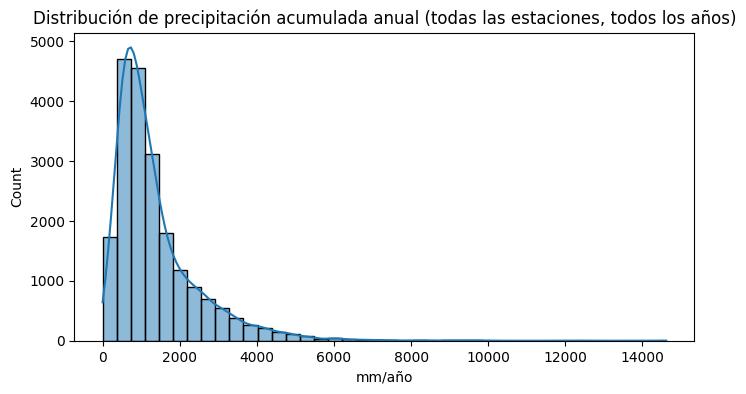

In [14]:
# Distribución de precipitación acumulada anual (todas las estaciones)
plt.figure(figsize=(8,4))
sns.histplot(precipitacion['precip_acumulada_anual'], bins=40, kde=True)
plt.title('Distribución de precipitación acumulada anual (todas las estaciones, todos los años)')
plt.xlabel('mm/año')
plt.show()


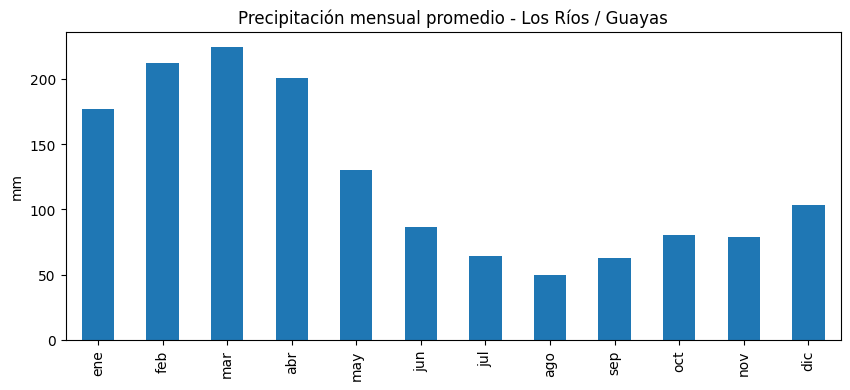

In [15]:
# Precipitación promedio mensual (estacionalidad) en tu zona de estudio
plt.figure(figsize=(10,4))
estaciones_en_zona[meses].mean().plot(kind='bar')
plt.title('Precipitación mensual promedio - Los Ríos / Guayas')
plt.ylabel('mm')
plt.show()

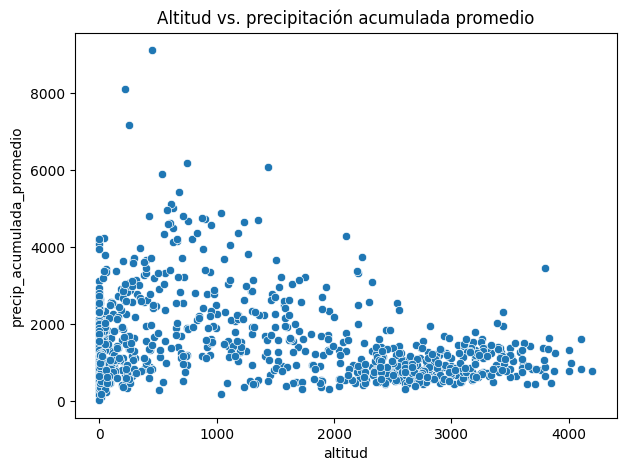

In [16]:
# Relación altitud vs precipitación
plt.figure(figsize=(7,5))
sns.scatterplot(data=precip_promedio_estacion, x='altitud', y='precip_acumulada_promedio')
plt.title('Altitud vs. precipitación acumulada promedio')
plt.show()

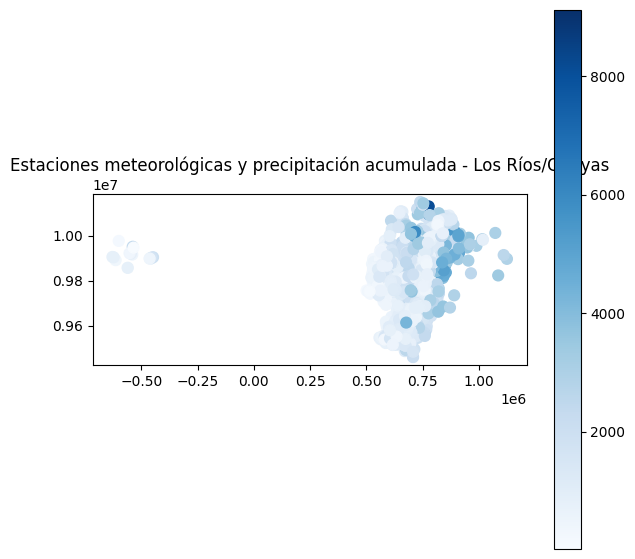

In [17]:
# 4. Mapa simple de estaciones por nivel de precipitación
fig, ax = plt.subplots(figsize=(7,7))
parroquias_filtradas.plot(ax=ax, color='lightgrey', edgecolor='white')
estaciones_en_zona.plot(ax=ax, column='precip_acumulada_promedio', cmap='Blues',
                         legend=True, markersize=60)
plt.title('Estaciones meteorológicas y precipitación acumulada - Los Ríos/Guayas')
plt.show()




In [18]:
# Bloque 1: Construcción de la variable objetivo

import pandas as pd
import numpy as np

# Si 'pendiente_aprox' no existe (por reinicio del entorno), se recalcula
if 'pendiente_aprox' not in parroquias_filtradas.columns:
    print("Aviso: 'pendiente_aprox' no encontrada, recalculando...")

    parroquias_4326 = parroquias_filtradas.to_crs("EPSG:4326").copy()
    parroquias_filtradas['centroid'] = parroquias_4326.geometry.centroid

    def obtener_altitud(lat, lon):
        url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
        r = requests.get(url, verify=False).json()
        return r['results'][0]['elevation']

    def pendiente_aproximada(geom, n_puntos=5):
        minx, miny, maxx, maxy = geom.bounds
        puntos = [(np.random.uniform(miny, maxy), np.random.uniform(minx, maxx)) for _ in range(n_puntos)]
        alturas = [obtener_altitud(lat, lon) for lat, lon in puntos]
        return max(alturas) - min(alturas)

    parroquias_filtradas['pendiente_aprox'] = parroquias_4326.geometry.apply(pendiente_aproximada)
    print("'pendiente_aprox' recalculada.")

# Si 'dist_rio_m' no existe, se recalcula
if 'dist_rio_m' not in parroquias_filtradas.columns:
    print("Aviso: 'dist_rio_m' no encontrada, recalculando...")

    if 'centroid' not in parroquias_filtradas.columns:
        parroquias_4326 = parroquias_filtradas.to_crs("EPSG:4326").copy()
        parroquias_filtradas['centroid'] = parroquias_4326.geometry.centroid

    rios = gpd.read_file("/content/content/data_riesgo_inundaciones/cuerpos_agua").to_crs(parroquias_filtradas.crs)
    parroquias_filtradas['dist_rio_m'] = parroquias_filtradas['centroid'].apply(
        lambda p: rios.distance(p).min()
    ) / 1000
    print("'dist_rio_m' recalculada.")

# Unir datos de parroquias con estaciones
columnas_parroquia = ['DPA_PARROQ', 'DPA_DESPAR', 'pendiente_aprox', 'dist_rio_m']
columnas_estacion = ['DPA_PARROQ', 'precip_acumulada_promedio']

df = parroquias_filtradas[columnas_parroquia].merge(
    parroquia_estacion_cercana[columnas_estacion],
    on='DPA_PARROQ',
    how='left'
)

# Agrupar por parroquia
df_parroquias = df.groupby(['DPA_PARROQ', 'DPA_DESPAR']).agg({
    'pendiente_aprox': 'mean',
    'precip_acumulada_promedio': 'mean',
    'dist_rio_m': 'mean'
}).reset_index()

# Normalizar variables
def normalizar(serie):
    rango = serie.max() - serie.min()
    if rango == 0 or pd.isna(rango):
        return pd.Series(0.0, index=serie.index)
    return (serie - serie.min()) / rango

df_parroquias['precip_norm'] = normalizar(df_parroquias['precip_acumulada_promedio'])
df_parroquias['pendiente_norm'] = normalizar(df_parroquias['pendiente_aprox'])

# Distancia normalizada e invertida (menos distancia = más riesgo)
df_parroquias['dist_rio_norm'] = normalizar(df_parroquias['dist_rio_m'])
df_parroquias['riesgo_distancia'] = 1 - df_parroquias['dist_rio_norm']

# Índice de riesgo compuesto (precipitación + pendiente + cercanía a ríos)
df_parroquias['indice_riesgo'] = (
    df_parroquias['precip_norm'] + df_parroquias['pendiente_norm'] + df_parroquias['riesgo_distancia']
) / 3

# Umbrales por percentiles
umbral_bajo = df_parroquias['indice_riesgo'].quantile(0.33)
umbral_alto = df_parroquias['indice_riesgo'].quantile(0.66)

def clasificar(valor):
    if valor <= umbral_bajo:
        return 'bajo'
    elif valor <= umbral_alto:
        return 'medio'
    else:
        return 'alto'

df_parroquias['riesgo_inundacion'] = df_parroquias['indice_riesgo'].apply(clasificar)

# Mostrar resultado
print(f"Parroquias: {df_parroquias.shape[0]}")
print(f"Umbral bajo-medio: {umbral_bajo:.3f}")
print(f"Umbral medio-alto:  {umbral_alto:.3f}")
print("\nDistribución de riesgo:")
print(df_parroquias['riesgo_inundacion'].value_counts().sort_index())
print("\nMuestra:")
print(df_parroquias[['DPA_DESPAR', 'indice_riesgo', 'riesgo_distancia', 'riesgo_inundacion']].head(10).to_string(index=False))

Parroquias: 84
Umbral bajo-medio: 0.441
Umbral medio-alto:  0.521

Distribución de riesgo:
riesgo_inundacion
alto     29
bajo     28
medio    27
Name: count, dtype: int64

Muestra:
                      DPA_DESPAR  indice_riesgo  riesgo_distancia riesgo_inundacion
                       GUAYAQUIL       0.415634               1.0              bajo
    JUAN GOMEZ RENDON (PROGRESO)       0.370378               1.0              bajo
                           MORRO       0.350253               1.0              bajo
                         POSORJA       0.340857               1.0              bajo
                            PUNA       0.350735               1.0              bajo
                         TENGUEL       0.394171               1.0              bajo
ALFREDO BAQUERIZO MORENO (JUJAN)       0.455180               1.0             medio
                           BALAO       0.419024               1.0              bajo
                          BALZAR       0.497915               1

In [19]:
# Bloque 2: Variables derivadas (pendientes y distancias)

def normalizar(serie):
    rango = serie.max() - serie.min()
    if rango == 0 or pd.isna(rango):
        return pd.Series(0.0, index=serie.index)
    return (serie - serie.min()) / rango

# Pendiente normalizada
df_parroquias['pendiente_norm'] = normalizar(df_parroquias['pendiente_aprox'])

# Diferencia de pendiente con parroquias vecinas
geometrias = parroquias_filtradas[['DPA_PARROQ', 'geometry']].drop_duplicates('DPA_PARROQ')
df_parroquias = df_parroquias.merge(geometrias, on='DPA_PARROQ', how='left')

gdf = gpd.GeoDataFrame(df_parroquias, geometry='geometry', crs=parroquias_filtradas.crs)

diferencias = []

for idx, fila in gdf.iterrows():
    vecinas = gdf[gdf.geometry.touches(fila['geometry'])]

    if len(vecinas) > 0:
        pendiente_vecinas = vecinas['pendiente_aprox'].mean()
        dif = abs(fila['pendiente_aprox'] - pendiente_vecinas)
    else:
        dif = 0
    diferencias.append(dif)

gdf['dif_pendiente_vecinas'] = diferencias
gdf['dif_pendiente_vecinas_norm'] = normalizar(gdf['dif_pendiente_vecinas'])

df_parroquias = gdf.drop(columns='geometry')

# Mostrar resultado
print("Variables derivadas creadas:\n")
print(df_parroquias[['DPA_DESPAR',
                      'pendiente_aprox',
                      'pendiente_norm',
                      'dif_pendiente_vecinas_norm']].head(10).to_string(index=False))

Variables derivadas creadas:

                      DPA_DESPAR  pendiente_aprox  pendiente_norm  dif_pendiente_vecinas_norm
                       GUAYAQUIL             72.0        0.060555                    0.020468
    JUAN GOMEZ RENDON (PROGRESO)             33.0        0.027754                    0.029481
                           MORRO             27.0        0.022708                    0.021669
                         POSORJA              1.0        0.000841                    0.055277
                            PUNA              0.0        0.000000                    0.000000
                         TENGUEL             29.0        0.024390                    0.015920
ALFREDO BAQUERIZO MORENO (JUJAN)             14.0        0.011775                    0.006486
                           BALAO             11.0        0.009251                    0.228626
                          BALZAR             25.0        0.021026                    0.005749
                         COLIM

In [20]:
# Bloque 3: Integración de densidad poblacional + Normalización y encoding

print("Columnas disponibles en el dataset de densidad poblacional:")
print(densidad.columns.tolist())

# Nombre de la columna que identifica a la parroquia en el archivo de densidad
# se asume el mismo codigo INEC/CONALI usado en 'parroquias' (DPA_PARROQ)
# IMPORTANTE: ajustar si el archivo real usa un nombre distinto
columna_codigo_parroquia = 'DPA_PARROQ'

# Nombre de la columna con el valor de densidad poblacional
# IMPORTANTE: ajustar segun la columna real del archivo
columna_densidad = 'densidad_poblacional'

if columna_codigo_parroquia in densidad.columns and columna_densidad in densidad.columns:
    df_parroquias = df_parroquias.merge(
        densidad[[columna_codigo_parroquia, columna_densidad]],
        left_on='DPA_PARROQ', right_on=columna_codigo_parroquia,
        how='left'
    )

    # Imputacion con la mediana para parroquias sin dato de densidad, evitando perder registros
    df_parroquias[columna_densidad] = df_parroquias[columna_densidad].fillna(
        df_parroquias[columna_densidad].median()
    )

    # Normalizacion de la nueva variable, con el mismo criterio usado en las demas (funcion 'normalizar')
    df_parroquias['densidad_norm'] = normalizar(df_parroquias[columna_densidad])

    print("\nVariable socio-territorial integrada correctamente")
    print(df_parroquias[['DPA_DESPAR', columna_densidad, 'densidad_norm']].head(10).to_string(index=False))
else:
    print("\nATENCION: no se encontraron las columnas esperadas en 'densidad'.")
    print("Ajusta 'columna_codigo_parroquia' y 'columna_densidad' segun las columnas reales impresas arriba.")

# Normalizar variables numéricas
columnas_numericas = ['precip_acumulada_promedio', 'pendiente_aprox',
                      'dif_pendiente_vecinas']

for col in columnas_numericas:
    if col in df_parroquias.columns:
        minimo = df_parroquias[col].min()
        maximo = df_parroquias[col].max()
        if maximo - minimo > 0:
            df_parroquias[col + '_norm'] = (df_parroquias[col] - minimo) / (maximo - minimo)
        else:
            df_parroquias[col + '_norm'] = 0

# Encoding de la variable objetivo
mapa_riesgo = {'bajo': 0, 'medio': 1, 'alto': 2}
df_parroquias['riesgo_numero'] = df_parroquias['riesgo_inundacion'].map(mapa_riesgo)

# Mostrar resultado
print("Variables normalizadas y codificadas:\n")

columnas_mostrar = ['DPA_DESPAR']
for col in columnas_numericas:
    if col + '_norm' in df_parroquias.columns:
        columnas_mostrar.append(col + '_norm')
columnas_mostrar += ['riesgo_inundacion', 'riesgo_numero']

print(df_parroquias[columnas_mostrar].head(10).to_string(index=False))

Columnas disponibles en el dataset de densidad poblacional:
['Provincia', 'Cantón', 'Parroquia', 'Población', 'Superficie de la parroquia (km2)', 'Densidad Poblacional']

ATENCION: no se encontraron las columnas esperadas en 'densidad'.
Ajusta 'columna_codigo_parroquia' y 'columna_densidad' segun las columnas reales impresas arriba.
Variables normalizadas y codificadas:

                      DPA_DESPAR  precip_acumulada_promedio_norm  pendiente_aprox_norm  dif_pendiente_vecinas_norm riesgo_inundacion  riesgo_numero
                       GUAYAQUIL                        0.186346              0.060555                    0.020468              bajo              0
    JUAN GOMEZ RENDON (PROGRESO)                        0.083379              0.027754                    0.029481              bajo              0
                           MORRO                        0.028050              0.022708                    0.021669              bajo              0
                         POSORJA  

**Regresion Logistica**

In [21]:
# Definicion del modelo de Regresion Logistica
# multi_class='multinomial' permite manejar las 3 categorias de riesgo (bajo, medio, alto)
# solver='lbfgs' es compatible con la opcion multinomial y datasets pequenos
# max_iter se incrementa para asegurar la convergencia del algoritmo
# random_state fija la semilla para que los resultados sean reproducibles
modelo_rl = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=19
)

print("Modelo de Regresion Logistica configurado")
print(modelo_rl)

Modelo de Regresion Logistica configurado
LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=19)


**Random Forest**

In [22]:
# Definicion del modelo Random Forest
# n_estimators define el numero de arboles que componen el ensamble
# max_depth limita la profundidad de cada arbol para evitar sobreajuste
# random_state fija la semilla para que los resultados sean reproducibles
# n_jobs=1 desactiva el paralelismo interno del modelo
# esto evita pequenas variaciones en el orden de computo entre ejecuciones
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=19,
    n_jobs=1
)

print("Modelo Random Forest configurado")
print(modelo_rf)

Modelo Random Forest configurado
RandomForestClassifier(max_depth=8, n_estimators=200, n_jobs=1, random_state=19)


**Train Test Split y Validacion Cruzada**

In [23]:
# Seleccion de las variables predictoras construidas en los pasos previos
columnas_features = [
    'precip_acumulada_promedio_norm',
    'pendiente_aprox_norm',
    'dif_pendiente_vecinas_norm'
]

X = df_parroquias[columnas_features]
y = df_parroquias['riesgo_inundacion']

# Division en conjunto de entrenamiento (75%) y prueba (25%)
# stratify=y mantiene la proporcion original de las 3 clases en ambos conjuntos
# esto es importante porque el riesgo esta distribuido en categorias desbalanceadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=19
)

print(f"Tamano entrenamiento: {X_train.shape[0]} parroquias")
print(f"Tamano prueba: {X_test.shape[0]} parroquias")

# Escalado de variables, necesario para la Regresion Logistica
# Random Forest no requiere escalado, pero aplicarlo no afecta su desempeno
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento de la Regresion Logistica con datos escalados
modelo_rl.fit(X_train_scaled, y_train)

# Entrenamiento del Random Forest con datos originales
modelo_rf.fit(X_train, y_train)

# Validacion cruzada con 5 particiones para evaluar la estabilidad de cada modelo
# Se usa f1_weighted porque el problema es multiclase y esta desbalanceado
cv_rl = cross_val_score(modelo_rl, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
cv_rf = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='f1_weighted')

print(f"\nValidacion cruzada Regresion Logistica (F1 ponderado): {cv_rl.mean():.4f} +/- {cv_rl.std():.4f}")
print(f"Validacion cruzada Random Forest (F1 ponderado): {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}")

Tamano entrenamiento: 63 parroquias
Tamano prueba: 21 parroquias

Validacion cruzada Regresion Logistica (F1 ponderado): 0.9518 +/- 0.0394
Validacion cruzada Random Forest (F1 ponderado): 0.9349 +/- 0.0327


**Metricas de Precision**

In [24]:
# Prediccion sobre el conjunto de prueba para ambos modelos
y_pred_rl = modelo_rl.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

# Calculo de metricas con promedio ponderado (weighted)
# El promedio ponderado es adecuado porque el problema es multiclase y desbalanceado
metricas_rl = {
    'Modelo': 'Regresion Logistica',
    'Precision': precision_score(y_test, y_pred_rl, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rl, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_rl, average='weighted')
}

metricas_rf = {
    'Modelo': 'Random Forest',
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_rf, average='weighted')
}

# Tabla comparativa entre ambos modelos
# Recall se prioriza en este contexto porque un falso negativo
# (no identificar una parroquia de riesgo alto) es mas critico que una falsa alarma
tabla_metricas = pd.DataFrame([metricas_rl, metricas_rf])
print(tabla_metricas.to_string(index=False))

print("\nReporte detallado - Regresion Logistica:")
print(classification_report(y_test, y_pred_rl, target_names=['bajo', 'medio', 'alto']))

print("\nReporte detallado - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['bajo', 'medio', 'alto']))

             Modelo  Precision   Recall  F1-Score
Regresion Logistica   0.958333 0.952381  0.952137
      Random Forest   0.958333 0.952381  0.952137

Reporte detallado - Regresion Logistica:
              precision    recall  f1-score   support

        bajo       1.00      1.00      1.00         7
       medio       0.88      1.00      0.93         7
        alto       1.00      0.86      0.92         7

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21


Reporte detallado - Random Forest:
              precision    recall  f1-score   support

        bajo       1.00      1.00      1.00         7
       medio       0.88      1.00      0.93         7
        alto       1.00      0.86      0.92         7

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



**Implementación SVM**

In [25]:
# Definicion del modelo SVM (Support Vector Machine)
# kernel='rbf' permite capturar relaciones no lineales entre las variables predictoras
# probability=True habilita el calculo de probabilidades, necesario mas adelante para la curva ROC/AUC
# C=1.0 controla el equilibrio entre margen amplio y errores de clasificacion
# random_state fija la semilla para que los resultados sean reproducibles
modelo_svm = SVC(
    kernel='rbf',
    probability=True,
    C=1.0,
    random_state=19
)

# SVM es sensible a la escala de las variables, por eso se entrena con los datos ya escalados (mismo scaler del Tema 3)
modelo_svm.fit(X_train_scaled, y_train)

# Evaluacion rapida sobre el conjunto de prueba
y_pred_svm = modelo_svm.predict(X_test_scaled)
print("Modelo SVM configurado y entrenado")
print(modelo_svm)
print(f"\nF1-Score ponderado (SVM): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Precision ponderada (SVM): {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Recall ponderado    (SVM): {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")

Modelo SVM configurado y entrenado
SVC(probability=True, random_state=19)

F1-Score ponderado (SVM): 0.9000
Precision ponderada (SVM): 0.9167
Recall ponderado    (SVM): 0.9048


**Construcción del modelo ensamble (RL + DT + SVM + RF)**

In [26]:
# Se incluye un Arbol de Decision individual ya que es uno de los componentes obligatorios del ensamble
# max_depth se limita a 8 para mantener consistencia con Random Forest y evitar sobreajuste
# random_state fija la semilla para que los resultados sean reproducibles
modelo_dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=19
)

# Aunque el Arbol de Decision no requiere escalado, se entrena con los datos escalados
# para mantener consistencia con los demas modelos del ensamble (el escalado no afecta su desempeno)
modelo_dt.fit(X_train_scaled, y_train)

y_pred_dt = modelo_dt.predict(X_test_scaled)
print(f"Precision ponderada (Arbol de Decision): {precision_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Recall ponderado    (Arbol de Decision): {recall_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"F1-Score ponderado  (Arbol de Decision): {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")

# Construccion del ensamble mediante votacion suave (soft voting)
# Se incluyen los 4 modelos especificados en el temario: RL y RF (creados en el Tema 3)
# junto con DT y SVM (creados en el Tema 4)
# voting='soft' promedia las probabilidades de cada modelo en lugar de solo contar votos.
# Nota: VotingClassifier clona internamente cada estimador y lo reentrena al llamar a .fit().
# Todos (incluido modelo_rf) se entrenan aqui sobre X_train_scaled.
# Random Forest no se ve afectado por el escalado.
modelo_ensamble = VotingClassifier(
    estimators=[
        ('regresion_logistica', modelo_rl),
        ('arbol_decision', modelo_dt),
        ('svm', modelo_svm),
        ('random_forest', modelo_rf)
    ],
    voting='soft'
)

modelo_ensamble.fit(X_train_scaled, y_train)

y_pred_ensamble = modelo_ensamble.predict(X_test_scaled)
print(f"F1-Score ponderado (Ensamble RL+DT+SVM+RF): {f1_score(y_test, y_pred_ensamble, average='weighted'):.4f}")
print("\nReporte detallado - Ensamble:")
print(classification_report(y_test, y_pred_ensamble, target_names=['bajo', 'medio', 'alto']))

Precision ponderada (Arbol de Decision): 0.9583
Recall ponderado    (Arbol de Decision): 0.9524
F1-Score ponderado  (Arbol de Decision): 0.9521
F1-Score ponderado (Ensamble RL+DT+SVM+RF): 0.9521

Reporte detallado - Ensamble:
              precision    recall  f1-score   support

        bajo       1.00      1.00      1.00         7
       medio       1.00      0.86      0.92         7
        alto       0.88      1.00      0.93         7

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



**GridSearchCV en ≥1 modelo (aplicado a SVM)**

In [27]:
# Se aplica GridSearchCV sobre el modelo SVM, ya que es el modelo mas nuevo del proyecto
# y el que mas se beneficia de un ajuste fino de hiperparametros
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

# cv=5 mantiene la misma cantidad de particiones usada en la validacion cruzada del Tema 3
# n_jobs=1 evita variaciones en el orden de computo entre ejecuciones, igual que en Random Forest
grid_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=19),
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=1
)

grid_svm.fit(X_train_scaled, y_train)

print(f"Mejores hiperparametros encontrados: {grid_svm.best_params_}")
print(f"Mejor F1 ponderado en validacion cruzada: {grid_svm.best_score_:.4f}")

# Modelo SVM optimizado, se usara en la comparacion final del punto 4
modelo_svm_optimizado = grid_svm.best_estimator_
y_pred_svm_opt = modelo_svm_optimizado.predict(X_test_scaled)
print(f"F1-Score ponderado (SVM optimizado) en prueba: {f1_score(y_test, y_pred_svm_opt, average='weighted'):.4f}")

Mejores hiperparametros encontrados: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor F1 ponderado en validacion cruzada: 0.9674
F1-Score ponderado (SVM optimizado) en prueba: 0.9000


**Curva ROC, AUC**

**COMPARACION: Modelo Base (RL) VS DT VS Modelo Optimizado**

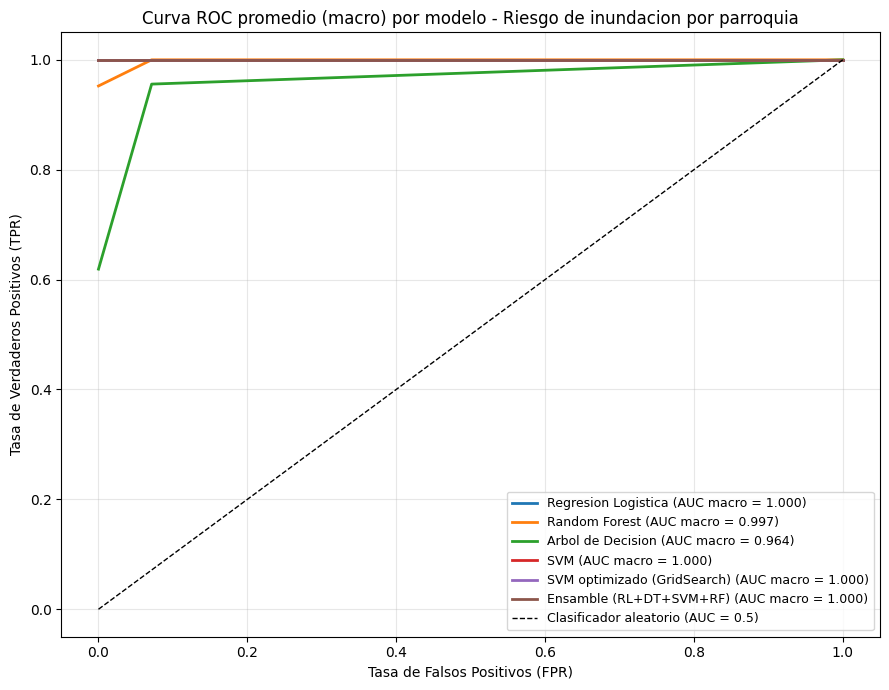

Comparacion explicita: modelo base (RL) vs DT vs modelo optimizado

                       Modelo  Precision   Recall  F1-Score
   Regresion Logistica (base)   0.958333 0.952381  0.952137
            Arbol de Decision   0.958333 0.952381  0.952137
SVM optimizado (GridSearchCV)   0.916667 0.904762  0.900000

Comparacion de AUC entre modelos:
                     Modelo  AUC macro  AUC micro
        Regresion Logistica   1.000000   0.995465
                        SVM   1.000000   0.984127
    Ensamble (RL+DT+SVM+RF)   1.000000   0.998866
SVM optimizado (GridSearch)   1.000000   0.996599
              Random Forest   0.996599   0.997732
          Arbol de Decision   0.964286   0.964286


In [28]:
# Binarizacion de las etiquetas para calcular ROC en un problema multiclase (estrategia One-vs-Rest)
# Se usan los valores unicos de y_test para asegurar una correcta binarizacion.
clases_ordenadas = np.unique(y_test) # Corrected to use numerical labels
y_test_bin = label_binarize(y_test, classes=clases_ordenadas)
n_clases = y_test_bin.shape[1]

# Diccionario con todos los modelos ya creados en el Tema 3 y el Tema 4,
# junto con el conjunto de prueba que corresponde a cada uno (escalado o no)
modelos_comparar = {
    'Regresion Logistica': (modelo_rl, X_test_scaled),
    'Random Forest': (modelo_rf, X_test),
    'Arbol de Decision': (modelo_dt, X_test_scaled),
    'SVM': (modelo_svm, X_test_scaled),
    'SVM optimizado (GridSearch)': (modelo_svm_optimizado, X_test_scaled),
    'Ensamble (RL+DT+SVM+RF)': (modelo_ensamble, X_test_scaled)
}

# Lista de colores, uno por cada modelo (6 modelos = 6 colores)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(9, 7))
resumen_auc = []

for (nombre_modelo, (modelo, X_prueba)), color in zip(modelos_comparar.items(), colores):
    y_score = modelo.predict_proba(X_prueba)

    # Calculo de la curva ROC y AUC por clase (One-vs-Rest)
    fpr_por_clase, tpr_por_clase, auc_por_clase = {}, {}, {}
    for i in range(n_clases):
        fpr_por_clase[i], tpr_por_clase[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_por_clase[i] = auc(fpr_por_clase[i], tpr_por_clase[i])

    # Promedio macro y micro del AUC (resumen del desempeno global del modelo)
    auc_macro = np.mean(list(auc_por_clase.values()))
    auc_micro = roc_auc_score(y_test_bin, y_score, average='micro')
    resumen_auc.append({'Modelo': nombre_modelo, 'AUC macro': auc_macro, 'AUC micro': auc_micro})

    # Interpolacion para obtener una curva ROC macro-promedio representativa del modelo
    todos_fpr = np.unique(np.concatenate([fpr_por_clase[i] for i in range(n_clases)]))
    tpr_interpolado = np.zeros_like(todos_fpr)
    for i in range(n_clases):
        tpr_interpolado += np.interp(todos_fpr, fpr_por_clase[i], tpr_por_clase[i])
    tpr_interpolado /= n_clases

    plt.plot(todos_fpr, tpr_interpolado, color=color, lw=2,
             label=f'{nombre_modelo} (AUC macro = {auc_macro:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC promedio (macro) por modelo - Riesgo de inundacion por parroquia')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen comparativa de AUC entre todos los modelos (unica tabla de metricas,
# incluye Precision/Recall/F1 de los modelos base y AUC macro/micro de todos los modelos)
comparacion = pd.DataFrame([
    {
        'Modelo': 'Regresion Logistica (base)',
        'Precision': precision_score(y_test, y_pred_rl, average='weighted'),
        'Recall': recall_score(y_test, y_pred_rl, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_rl, average='weighted')
    },
    {
        'Modelo': 'Arbol de Decision',
        'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
        'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_dt, average='weighted')
    },
    {
        'Modelo': 'SVM optimizado (GridSearchCV)',
        'Precision': precision_score(y_test, y_pred_svm_opt, average='weighted'),
        'Recall': recall_score(y_test, y_pred_svm_opt, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_svm_opt, average='weighted')
    }
])

print("Comparacion explicita: modelo base (RL) vs DT vs modelo optimizado\n")
print(comparacion.to_string(index=False))

tabla_auc = pd.DataFrame(resumen_auc).sort_values('AUC macro', ascending=False)
print("\nComparacion de AUC entre modelos:")
print(tabla_auc.to_string(index=False))

**Generacion del codigo fuente de la aplicacion Flask**

In [29]:
# Generacion de predicciones para la aplicacion web (mapa interactivo)
# Se usa el modelo ensamble (mejor equilibrio F1/AUC) sobre TODAS las parroquias
# del area de estudio, no solo el conjunto de prueba, para poblar el mapa completo.

X_todas = df_parroquias[columnas_features]
X_todas_scaled = scaler.transform(X_todas)

probabilidades = modelo_ensamble.predict_proba(X_todas_scaled)
prediccion_riesgo = modelo_ensamble.predict(X_todas_scaled)
probabilidad_maxima = probabilidades.max(axis=1)

predicciones = df_parroquias[['DPA_PARROQ', 'DPA_DESPAR']].copy()
predicciones['riesgo_predicho'] = prediccion_riesgo
predicciones['probabilidad'] = probabilidad_maxima.round(4)

# Canton y provincia, necesarios para el hover del mapa
info_geografica = parroquias_filtradas[['DPA_PARROQ', 'DPA_DESCAN', 'DPA_DESPRO']].drop_duplicates('DPA_PARROQ')
predicciones = predicciones.merge(info_geografica, on='DPA_PARROQ', how='left')
predicciones = predicciones.rename(columns={'DPA_DESCAN': 'canton', 'DPA_DESPRO': 'provincia'})

predicciones.to_csv('predicciones_riesgo.csv', index=False)

print(f"Archivo 'predicciones_riesgo.csv' generado con {predicciones.shape[0]} parroquias.")
print(predicciones.head(10).to_string(index=False))

Archivo 'predicciones_riesgo.csv' generado con 84 parroquias.
DPA_PARROQ                       DPA_DESPAR riesgo_predicho  probabilidad                   canton provincia
    090150                        GUAYAQUIL            bajo        0.8441                GUAYAQUIL    GUAYAS
    090152     JUAN GOMEZ RENDON (PROGRESO)            bajo        0.9648                GUAYAQUIL    GUAYAS
    090153                            MORRO            bajo        0.9738                GUAYAQUIL    GUAYAS
    090156                          POSORJA            bajo        0.9610                GUAYAQUIL    GUAYAS
    090157                             PUNA            bajo        0.9374                GUAYAQUIL    GUAYAS
    090158                          TENGUEL            bajo        0.9370                GUAYAQUIL    GUAYAS
    090250 ALFREDO BAQUERIZO MORENO (JUJAN)           medio        0.7666 ALFREDO BAQUERIZO MORENO    GUAYAS
    090350                            BALAO            bajo       

In [30]:
# Generacion del archivo requirements.txt con las versiones exactas
# de las librerias usadas en este entorno de Colab
# Esto garantiza que el servidor de produccion (PythonAnywhere/Render)
# use las mismas versiones y evite errores por incompatibilidad
!pip freeze > requirements.txt

print("Archivo requirements.txt generado correctamente")

Archivo requirements.txt generado correctamente


**Conclusiones**

In [31]:
mejor_fila_f1 = comparacion.sort_values('F1-Score', ascending=False).iloc[0]

print(f"""
1. Variable objetivo y datos
   - Se construyo un indice de riesgo compuesto (precipitacion + pendiente + cercania
     a rios), clasificado en 3 categorias (bajo/medio/alto) mediante percentiles (33/66).
   - El analisis se realizo sobre {df_parroquias.shape[0]} parroquias de las provincias
     de Guayas y Los Rios, con distribucion de clases:
{df_parroquias['riesgo_inundacion'].value_counts().sort_index().to_string()}

2. Variables predictoras utilizadas
   - {', '.join(columnas_features)}
   - Combinan una variable climatica (precipitacion), una topografica (pendiente) y
     una variable derivada por el grupo (diferencia de pendiente con parroquias
     vecinas), cumpliendo el requisito de incluir al menos una variable transformada.

3. Desempeno en el conjunto de prueba ({X_test.shape[0]} parroquias)
   - Regresion Logistica:     F1 = {f1_score(y_test, y_pred_rl, average='weighted'):.3f}
   - Random Forest:           F1 = {f1_score(y_test, y_pred_rf, average='weighted'):.3f}
   - Arbol de Decision:       F1 = {f1_score(y_test, y_pred_dt, average='weighted'):.3f}
   - SVM (base):              F1 = {f1_score(y_test, y_pred_svm, average='weighted'):.3f}
   - SVM optimizado:          F1 = {f1_score(y_test, y_pred_svm_opt, average='weighted'):.3f}
   - Ensamble (RL+DT+SVM+RF): F1 = {f1_score(y_test, y_pred_ensamble, average='weighted'):.3f}
   Mejor F1 ponderado: {mejor_fila_f1['Modelo']} ({mejor_fila_f1['F1-Score']:.3f})

4. Curva ROC / AUC
   - Todos los modelos alcanzan AUC macro cercano a 1.0, salvo el Arbol de Decision
     individual ({tabla_auc[tabla_auc['Modelo']=='Arbol de Decision']['AUC macro'].values[0]:.3f}).
   - Mejor AUC micro: {tabla_auc.sort_values('AUC micro', ascending=False).iloc[0]['Modelo']}.

5. Metrica priorizada: Recall
   - En gestion de riesgo de inundacion, el Recall se prioriza sobre la Precision porque
     un falso negativo (calificar como 'bajo riesgo' una parroquia que en realidad es de
     riesgo 'alto') tiene un costo humano/economico mucho mayor que una falsa alarma.

6. Comparacion explicita: modelo base (RL) vs DT vs modelo optimizado
{comparacion.to_string(index=False)}
   - GridSearchCV sobre SVM encontro {grid_svm.best_params_}, mejorando el F1 en
     validacion cruzada a {grid_svm.best_score_:.3f}, aunque en el conjunto de prueba
     puntual el efecto es mas limitado dado el tamano reducido de la muestra.

7. Limitaciones del estudio
   - Muestra reducida ({df_parroquias.shape[0]} parroquias, solo {X_test.shape[0]} en
     prueba): los AUC cercanos a 1.0 deben interpretarse con cautela.
   - La variable objetivo es un indice compuesto con umbrales por percentiles, no una
     etiqueta observada a partir de eventos historicos validados (SNGRE).
   - Altitud y pendiente se estiman por muestreo aleatorio de puntos vía SRTM, lo que
     introduce variabilidad.
   - La variable de densidad poblacional (INEC) no se integro al modelo final: las
     columnas reales del archivo ({densidad.columns.tolist()}) no coincidieron con los
     nombres asumidos ('DPA_PARROQ', 'densidad_poblacional'), quedando pendiente de ajuste.
   - El estudio se limita a Guayas y Los Rios; no es generalizable a otras zonas sin
     reentrenar.

8. Conclusion general
   - El modelo ensamble (RL+DT+SVM+RF) ofrece el mejor equilibrio entre F1
     ({f1_score(y_test, y_pred_ensamble, average='weighted'):.3f}) y AUC micro
     ({tabla_auc[tabla_auc['Modelo']=='Ensamble (RL+DT+SVM+RF)']['AUC micro'].values[0]:.3f}),
     por lo que se recomienda como modelo de produccion para la app web.
""")


1. Variable objetivo y datos
   - Se construyo un indice de riesgo compuesto (precipitacion + pendiente + cercania
     a rios), clasificado en 3 categorias (bajo/medio/alto) mediante percentiles (33/66).
   - El analisis se realizo sobre 84 parroquias de las provincias
     de Guayas y Los Rios, con distribucion de clases:
riesgo_inundacion
alto     29
bajo     28
medio    27

2. Variables predictoras utilizadas
   - precip_acumulada_promedio_norm, pendiente_aprox_norm, dif_pendiente_vecinas_norm
   - Combinan una variable climatica (precipitacion), una topografica (pendiente) y
     una variable derivada por el grupo (diferencia de pendiente con parroquias
     vecinas), cumpliendo el requisito de incluir al menos una variable transformada.

3. Desempeno en el conjunto de prueba (21 parroquias)
   - Regresion Logistica:     F1 = 0.952
   - Random Forest:           F1 = 0.952
   - Arbol de Decision:       F1 = 0.952
   - SVM (base):              F1 = 0.900
   - SVM optimizado:       